# Multivariate Linear Regression

### Predicting Pricing

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

In [38]:
q3_2024 = pd.read_csv('../../data/2024_q3.csv')
q4_2024 = pd.read_csv('../../data/2024_q4.csv')
q1_2025 = pd.read_csv('../../data/2025_q1.csv')
q2_2025 = pd.read_csv('../../data/2025_q2.csv')

df = pd.concat([q3_2024, q4_2024, q1_2025, q2_2025], ignore_index=True)

df = df[df['REPORTING_CARRIER'] != '99']
df = df[df['TICKET_CARRIER'] != '99']
df = df[df['OPERATING_CARRIER'] != '99']

df.shape

(27378923, 15)

In [39]:
df["SAME_CARRIER"] = df['TICKET_CARRIER'] == df['OPERATING_CARRIER']

df["SAME_CARRIER"] = df["SAME_CARRIER"].astype(int)

df["SAME_CARRIER"].value_counts()

SAME_CARRIER
1    23609712
0     3769211
Name: count, dtype: int64

In [40]:
hhi = pd.read_csv('../../data/airport_hhi.csv')

In [41]:
df.shape

(27378923, 16)

In [42]:
df.columns

Index(['YEAR', 'QUARTER', 'ORIGIN_AIRPORT_ID', 'ORIGIN', 'DEST_AIRPORT_ID',
       'DEST', 'REPORTING_CARRIER', 'TICKET_CARRIER', 'OPERATING_CARRIER',
       'BULK_FARE', 'PASSENGERS', 'MARKET_FARE', 'MARKET_DISTANCE',
       'NONSTOP_MILES', 'MKT_GEO_TYPE', 'SAME_CARRIER'],
      dtype='object')

In [43]:
df = df.merge(hhi, left_on='ORIGIN', right_on='ORIGIN', how='left')

df.shape

(27378923, 17)

In [44]:
df.columns

Index(['YEAR', 'QUARTER', 'ORIGIN_AIRPORT_ID', 'ORIGIN', 'DEST_AIRPORT_ID',
       'DEST', 'REPORTING_CARRIER', 'TICKET_CARRIER', 'OPERATING_CARRIER',
       'BULK_FARE', 'PASSENGERS', 'MARKET_FARE', 'MARKET_DISTANCE',
       'NONSTOP_MILES', 'MKT_GEO_TYPE', 'SAME_CARRIER', 'HHI'],
      dtype='object')

In [45]:
df = df.loc[:,['SAME_CARRIER','HHI','MARKET_FARE','MARKET_DISTANCE']]

df.columns

Index(['SAME_CARRIER', 'HHI', 'MARKET_FARE', 'MARKET_DISTANCE'], dtype='object')

In [46]:
X = df.drop(columns=['MARKET_FARE'])
Y = df['MARKET_FARE']


print(X.shape, Y.shape)

(27378923, 3) (27378923,)


In [47]:

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np


# Split data
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=5200)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R^2:", r2)

print("Coefficients:\n", model.coef_)
print("Intercept:\n", model.intercept_)



MSE: 42860.5929213326
RMSE: 207.0280003316764
R^2: 0.09318221673860938
Coefficients:
 [-4.93951902e+01 -3.73253827e-03  8.43183557e-02]
Intercept:
 207.05827493830637


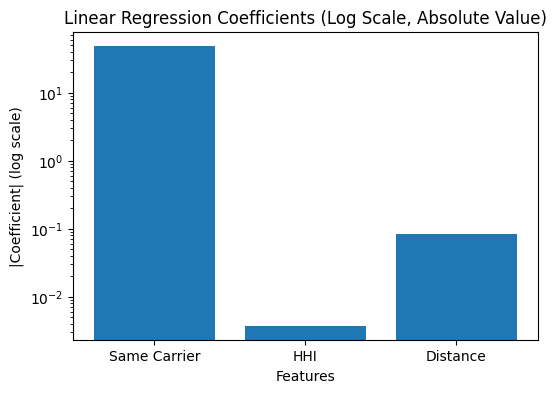

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

coefficients = model.coef_

plt.figure(figsize=(6, 4))
plt.bar(["Same Carrier","HHI","Distance"], np.abs(coefficients))

plt.yscale('log')

plt.title("Linear Regression Coefficients (Log Scale, Absolute Value)")
plt.xlabel("Features")
plt.ylabel("|Coefficient| (log scale)")

plt.show()